In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [12]:
PATH = R"C:\Users\20241CSE0725\Downloads\CSE2267-ML-Lab-Dataset-Students\Salary_Data.csv"
data = pd.read_csv(PATH)

In [14]:
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [17]:
data.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


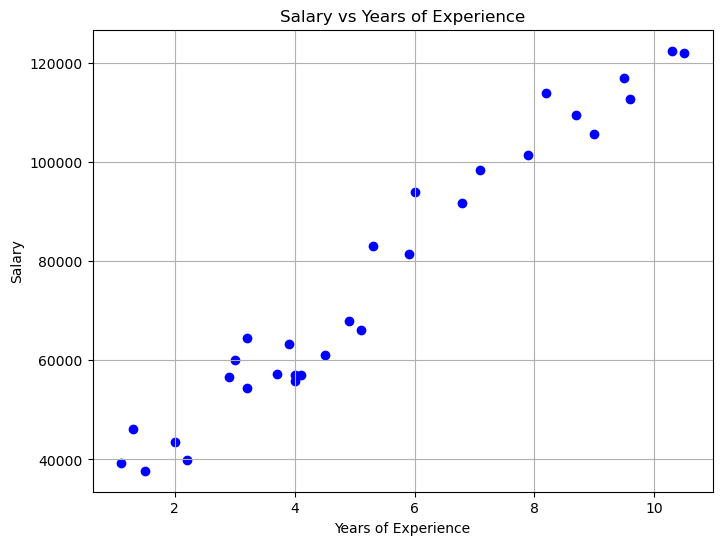

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(data["YearsExperience"], data["Salary"], color="blue")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Years of Experience")
plt.grid(True)
plt.show() 

In [32]:
X = data[["YearsExperience"]]
y = data["Salary"]
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
 X,
 y,
 test_size=0.30,
 random_state=42 
)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
# Evaluation Metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)
print("\n========== Linear Regression ==========")
print("Intercept :", linear_model.intercept_)
print("Coefficient :", linear_model.coef_[0])
print("\nMAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R2 Score:", r2_linear) 


========== Linear Regression ==========
Intercept : 25918.438334893217
Coefficient : 9339.081723815194

MAE : 5161.328710400186
MSE : 37784662.46621317
RMSE: 6146.923007994583
R2 Score: 0.9414466227178214


In [37]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

In [38]:
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print("\n========== Polynomial Regression ==========")
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE:", rmse_poly)
print("R2 Score:", r2_poly)
# Comparison Table
comparison = pd.DataFrame({
 "Metric":["MAE","MSE","RMSE","R2 Score"],
 "Linear Regression":[
 mae_linear,
 mse_linear,
 rmse_linear,
 r2_linear
 ],
 "Polynomial Regression":[
 mae_poly,
 mse_poly,
 rmse_poly,
 r2_poly
 ]
})
print("\nComparison of Models")
print(comparison)


========== Polynomial Regression ==========
MAE : 5199.782073940209
MSE : 38366233.44282797
RMSE: 6194.048227357289
R2 Score: 0.940545385480608

Comparison of Models
     Metric  Linear Regression  Polynomial Regression
0       MAE       5.161329e+03           5.199782e+03
1       MSE       3.778466e+07           3.836623e+07
2      RMSE       6.146923e+03           6.194048e+03
3  R2 Score       9.414466e-01           9.405454e-01


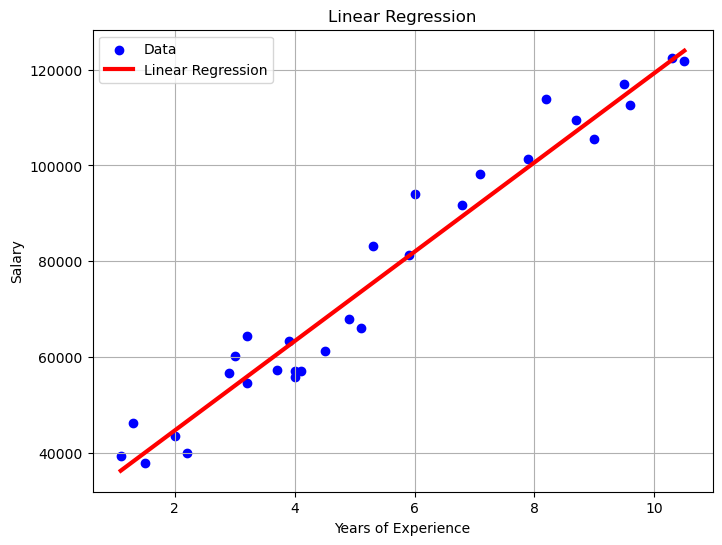

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, color="blue", label="Data")
plt.plot(
 X,
 linear_model.predict(X),
 color="red",
 linewidth=3,
 label="Linear Regression"
)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression")
plt.legend()
plt.grid(True)
plt.show() 

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


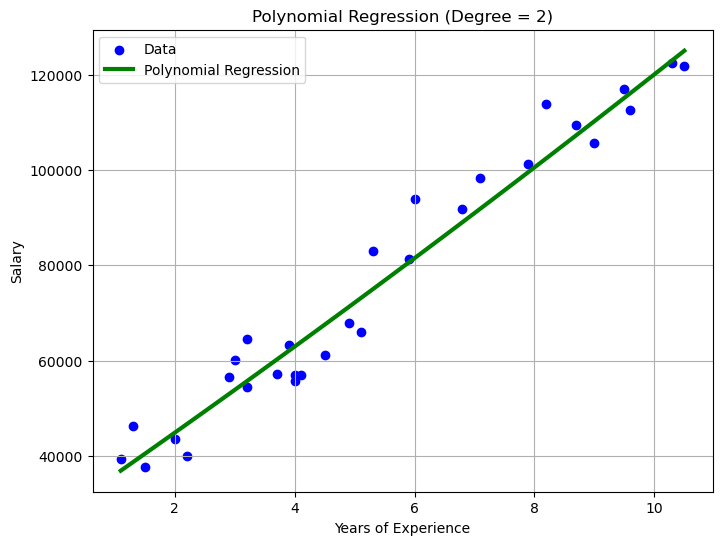

In [40]:
X_grid = np.linspace(
 X.min(),
 X.max(),
 100
).reshape(-1,1)
X_grid_poly = poly.transform(X_grid)
plt.figure(figsize=(8,6))
plt.scatter(X, y, color="blue", label="Data")
plt.plot(
 X_grid,
 poly_model.predict(X_grid_poly),
 color="green",
 linewidth=3,
 label="Polynomial Regression"
)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Polynomial Regression (Degree = 2)")
plt.legend()
plt.grid(True)
plt.show() 

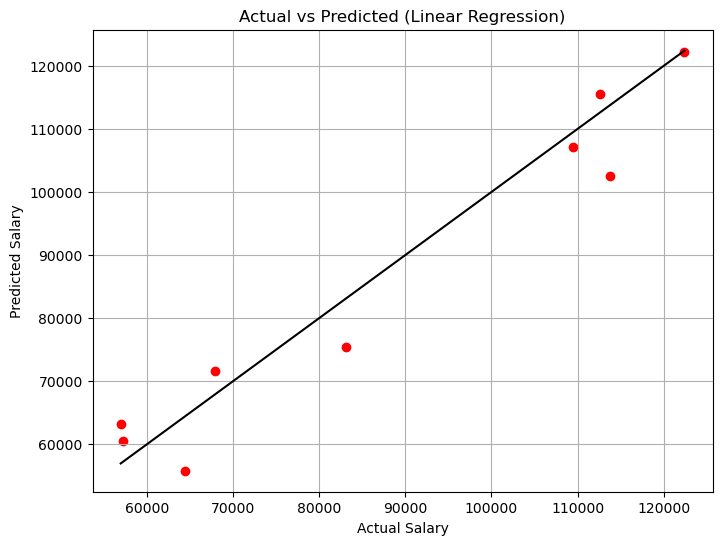

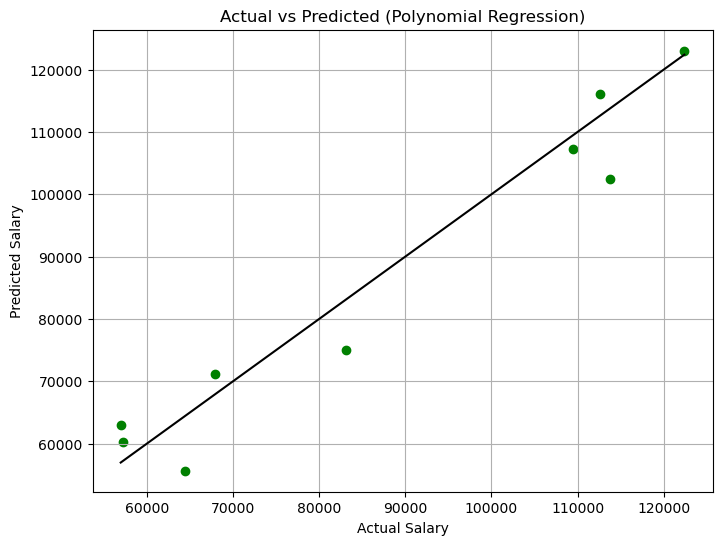

In [41]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_linear, color="red")
plt.plot(
 [y_test.min(), y_test.max()],
 [y_test.min(), y_test.max()],
 color="black"
)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted (Linear Regression)")
plt.grid(True)
plt.show()
# Actual vs Predicted (Polynomial)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_poly, color="green")
plt.plot(
 [y_test.min(), y_test.max()],
 [y_test.min(), y_test.max()],
 color="black"
)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted (Polynomial Regression)")
plt.grid(True)
plt.show() 